<a href="https://colab.research.google.com/github/Arhanabdullah/College-ML-Assignment/blob/main/Assignment-05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset loaded successfully:


,Fertilizer (kg/acre),Yield (quintals/acre)
0,10,20
1,12,18
2,30,40
3,25,31
4,50,60



Basic information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Fertilizer (kg/acre)   10 non-null     int64
 1   Yield (quintals/acre)  10 non-null     int64
dtypes: int64(2)
memory usage: 292.0 bytes

Checking for missing values:


,0
Fertilizer (kg/acre),0
Yield (quintals/acre),0


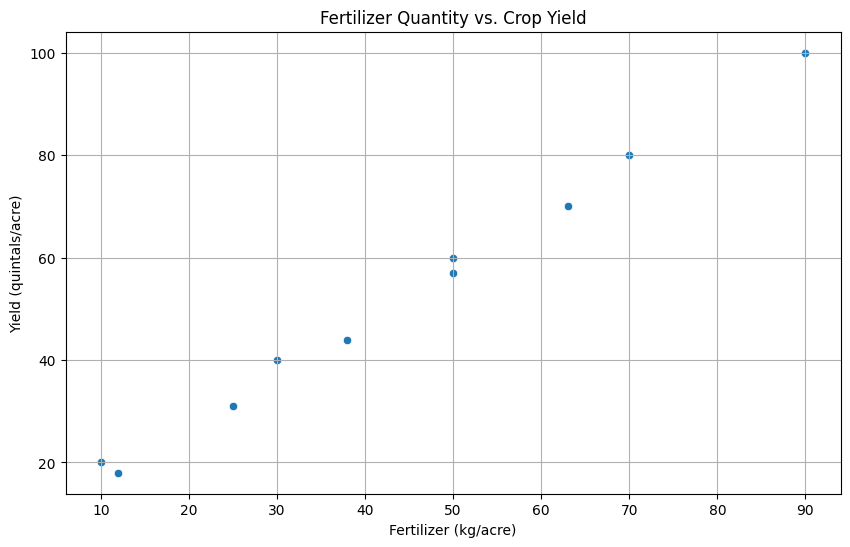


Training data points: 8
Testing data points: 2

Linear Regression model trained successfully.

Coefficient (slope): 1.00
Intercept: 8.29

Predictions for test data:


,Actual Yield,Predicted Yield
8,100,98.199045
1,18,20.281847



Model Evaluation Metrics:
Mean Absolute Error (MAE): 2.04
Mean Squared Error (MSE): 4.23
Root Mean Squared Error (RMSE): 2.06
R² Score: 1.00


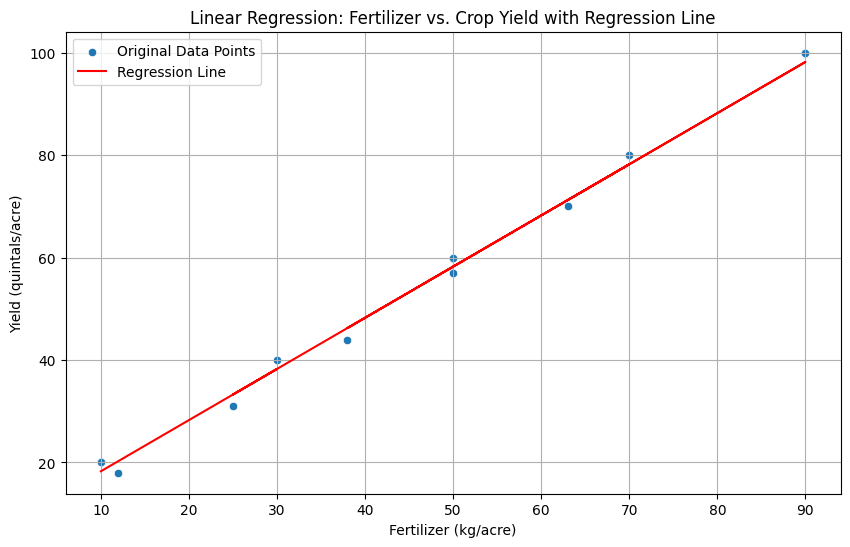


Predicted yield for 65 kg/acre fertilizer: 73.23 quintals/acre

--- Model Fit Explanation ---
The R² score of 1.00 indicates a strong fit. Approximately 100% of the variance in crop yield can be explained by the amount of fertilizer used. The MAE and RMSE values are relatively small compared to the range of the yield data, suggesting that the model's predictions are, on average, close to the actual values. This model appears to provide a good fit for predicting crop yield based on fertilizer quantity.


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

data = {
    'Fertilizer (kg/acre)': [10, 12, 30, 25, 50, 38, 70, 50, 90, 63],
    'Yield (quintals/acre)': [20, 18, 40, 31, 60, 44, 80, 57, 100, 70]
}

df = pd.DataFrame(data)
print("Dataset loaded successfully:")
display(df.head())


print("\nBasic information about the dataset:")
df.info()

print("\nChecking for missing values:")
display(df.isnull().sum())


plt.figure(figsize=(10, 6))
sns.scatterplot(x='Fertilizer (kg/acre)', y='Yield (quintals/acre)', data=df)
plt.title('Fertilizer Quantity vs. Crop Yield')
plt.xlabel('Fertilizer (kg/acre)')
plt.ylabel('Yield (quintals/acre)')
plt.grid(True)
plt.show()

X = df[['Fertilizer (kg/acre)']]
y = df['Yield (quintals/acre)']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTraining data points: {len(X_train)}")
print(f"Testing data points: {len(X_test)}")


model = LinearRegression()
model.fit(X_train, y_train)

print("\nLinear Regression model trained successfully.")


print(f"\nCoefficient (slope): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")

y_pred = model.predict(X_test)

print("\nPredictions for test data:")
predictions_df = pd.DataFrame({'Actual Yield': y_test, 'Predicted Yield': y_pred.flatten()})
display(predictions_df)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Fertilizer (kg/acre)', y='Yield (quintals/acre)', data=df, label='Original Data Points')
plt.plot(X, model.predict(X), color='red', label='Regression Line')
plt.title('Linear Regression: Fertilizer vs. Crop Yield with Regression Line')
plt.xlabel('Fertilizer (kg/acre)')
plt.ylabel('Yield (quintals/acre)')
plt.grid(True)
plt.legend()
plt.show()

fertilizer_quantity = np.array([[65]])
predicted_yield = model.predict(fertilizer_quantity)[0]

print(f"\nPredicted yield for {fertilizer_quantity[0][0]} kg/acre fertilizer: {predicted_yield:.2f} quintals/acre")

print("\n--- Model Fit Explanation ---")
if r2 >= 0.7:
    fit_message = "The R² score of {:.2f} indicates a strong fit. Approximately {:.0f}% of the variance in crop yield can be explained by the amount of fertilizer used. The MAE and RMSE values are relatively small compared to the range of the yield data, suggesting that the model's predictions are, on average, close to the actual values. This model appears to provide a good fit for predicting crop yield based on fertilizer quantity.".format(r2, r2*100)
elif r2 >= 0.5:
    fit_message = "The R² score of {:.2f} indicates a moderate fit. Approximately {:.0f}% of the variance in crop yield can be explained by the amount of fertilizer used. The MAE and RMSE values give an idea of the typical prediction error. While not perfect, the model shows a reasonable ability to predict crop yield based on fertilizer quantity.".format(r2, r2*100)
else:
    fit_message = "The R² score of {:.2f} indicates a weak fit. Only approximately {:.0f}% of the variance in crop yield can be explained by the amount of fertilizer used. The MAE and RMSE values suggest that there might be a significant error in the predictions. This model may not be ideal for accurately predicting crop yield based on fertilizer quantity alone, and other factors or a more complex model might be needed.".format(r2, r2*100)

print(fit_message)


Multiple Linear Regression Dataset loaded successfully:


,Engine Size (L),Weight (kg),Mileage (km/l)
0,1.0,900,22.5
1,1.2,950,20.8
2,1.5,1050,18.2
3,1.8,1150,16.0
4,2.0,1250,14.5



Basic information about the dataset (MLR):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Engine Size (L)  10 non-null     float64
 1   Weight (kg)      10 non-null     int64  
 2   Mileage (km/l)   10 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 372.0 bytes

Checking for missing values (MLR):


,0
Engine Size (L),0
Weight (kg),0
Mileage (km/l),0


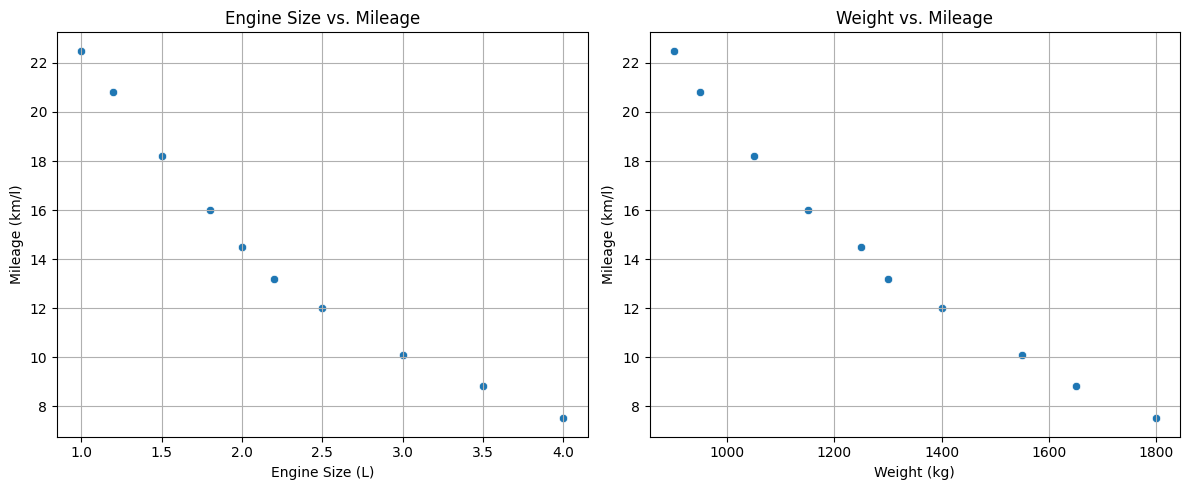


Training data points (MLR): 8
Testing data points (MLR): 2

Multiple Linear Regression model trained successfully.

Coefficients: [ 8.82197355 -0.04485046]
Intercept: 52.71

Interpretation of Coefficients:
  - For every 1 unit increase in Engine Size (L), Mileage decreases by approximately 8.82 km/l, holding Weight constant.
  - For every 1 unit increase in Weight (kg), Mileage decreases by approximately -0.0449 km/l, holding Engine Size constant.
  - The Intercept (52.71) represents the predicted Mileage when both Engine Size and Weight are zero (which is not practically meaningful in this context but is a necessary part of the linear equation).

Predictions for test data (MLR):


,Actual Mileage,Predicted Mileage
8,8.8,9.579807
1,20.8,20.684588



Model Evaluation Metrics (MLR):
Mean Absolute Error (MAE): 0.45
Mean Squared Error (MSE): 0.31
Root Mean Squared Error (RMSE): 0.56
R² Score: 0.99


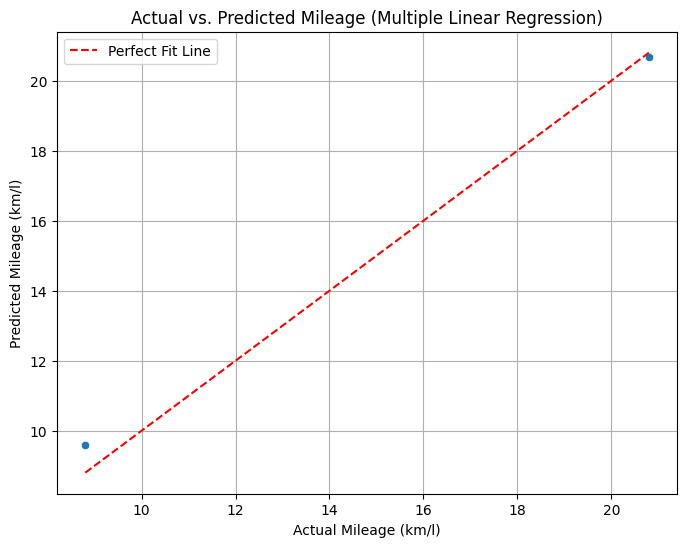

Predicted mileage for a car with Engine Size 2.8 L and Weight 1450 kg: 12.37 km/l

--- Model Fit and Feature Influence Explanation (MLR) ---
The R² score of 0.99 indicates a strong fit. Approximately 99% of the variance in car mileage can be explained by Engine Size and Weight. The MAE and RMSE values are relatively small, suggesting good predictive accuracy. This model appears to provide a good fit.

Feature Influence:
  - Absolute Coefficient for Engine Size: 8.82
  - Absolute Coefficient for Weight: 0.0449
Based on the absolute values of the coefficients, **Engine Size (L)** appears to have a greater influence on predicting car mileage than Weight (kg) in this model. A change in engine size has a larger impact on the predicted mileage than an equivalent change in weight.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

data_mlr = {
    'Engine Size (L)': [1.0, 1.2, 1.5, 1.8, 2.0, 2.2, 2.5, 3.0, 3.5, 4.0],
    'Weight (kg)': [900, 950, 1050, 1150, 1250, 1300, 1400, 1550, 1650, 1800],
    'Mileage (km/l)': [22.5, 20.8, 18.2, 16.0, 14.5, 13.2, 12.0, 10.1, 8.8, 7.5]
}

df_mlr = pd.DataFrame(data_mlr)

print("Multiple Linear Regression Dataset loaded successfully:")
display(df_mlr.head())

print("\nBasic information about the dataset (MLR):")
df_mlr.info()

print("\nChecking for missing values (MLR):")
display(df_mlr.isnull().sum())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x='Engine Size (L)', y='Mileage (km/l)', data=df_mlr)
plt.title('Engine Size vs. Mileage')
plt.xlabel('Engine Size (L)')
plt.ylabel('Mileage (km/l)')
plt.grid(True)

plt.subplot(1, 2, 2)
sns.scatterplot(x='Weight (kg)', y='Mileage (km/l)', data=df_mlr)
plt.title('Weight vs. Mileage')
plt.xlabel('Weight (kg)')
plt.ylabel('Mileage (km/l)')
plt.grid(True)

plt.tight_layout()
plt.show()

X_mlr = df_mlr[['Engine Size (L)', 'Weight (kg)']]
y_mlr = df_mlr['Mileage (km/l)']

X_train_mlr, X_test_mlr, y_train_mlr, y_test_mlr = train_test_split(X_mlr, y_mlr, test_size=0.2, random_state=42)

print(f"\nTraining data points (MLR): {len(X_train_mlr)}")
print(f"Testing data points (MLR): {len(X_test_mlr)}")

mlr_model = LinearRegression()
mlr_model.fit(X_train_mlr, y_train_mlr)

print("\nMultiple Linear Regression model trained successfully.")

print(f"\nCoefficients: {mlr_model.coef_}")
print(f"Intercept: {mlr_model.intercept_:.2f}")

print("\nInterpretation of Coefficients:")
print(f"  - For every 1 unit increase in Engine Size (L), Mileage decreases by approximately {mlr_model.coef_[0]:.2f} km/l, holding Weight constant.")
print(f"  - For every 1 unit increase in Weight (kg), Mileage decreases by approximately {mlr_model.coef_[1]:.4f} km/l, holding Engine Size constant.")
print(f"  - The Intercept ({mlr_model.intercept_:.2f}) represents the predicted Mileage when both Engine Size and Weight are zero (which is not practically meaningful in this context but is a necessary part of the linear equation).")

y_pred_mlr = mlr_model.predict(X_test_mlr)

print("\nPredictions for test data (MLR):")
predictions_df_mlr = pd.DataFrame({'Actual Mileage': y_test_mlr, 'Predicted Mileage': y_pred_mlr})
display(predictions_df_mlr)

mae_mlr = mean_absolute_error(y_test_mlr, y_pred_mlr)
mse_mlr = mean_squared_error(y_test_mlr, y_pred_mlr)
rmse_mlr = np.sqrt(mse_mlr)
r2_mlr = r2_score(y_test_mlr, y_pred_mlr)

print("\nModel Evaluation Metrics (MLR):")
print(f"Mean Absolute Error (MAE): {mae_mlr:.2f}")
print(f"Mean Squared Error (MSE): {mse_mlr:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_mlr:.2f}")
print(f"R² Score: {r2_mlr:.2f}")

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_mlr, y=y_pred_mlr)
plt.plot([min(y_test_mlr), max(y_test_mlr)], [min(y_test_mlr), max(y_test_mlr)], color='red', linestyle='--', label='Perfect Fit Line')
plt.title('Actual vs. Predicted Mileage (Multiple Linear Regression)')
plt.xlabel('Actual Mileage (km/l)')
plt.ylabel('Predicted Mileage (km/l)')
plt.grid(True)
plt.legend()
plt.show()

new_car_features = pd.DataFrame({
    'Engine Size (L)': [2.8],
    'Weight (kg)': [1450]
})

predicted_mileage_new_car = mlr_model.predict(new_car_features)[0]

print(f"Predicted mileage for a car with Engine Size 2.8 L and Weight 1450 kg: {predicted_mileage_new_car:.2f} km/l")

print("\n--- Model Fit and Feature Influence Explanation (MLR) ---")

if r2_mlr >= 0.7:
    fit_message_mlr = "The R² score of {:.2f} indicates a strong fit. Approximately {:.0f}% of the variance in car mileage can be explained by Engine Size and Weight. The MAE and RMSE values are relatively small, suggesting good predictive accuracy. This model appears to provide a good fit.".format(r2_mlr, r2_mlr*100)
elif r2_mlr >= 0.5:
    fit_message_mlr = "The R² score of {:.2f} indicates a moderate fit. Approximately {:.0f}% of the variance in car mileage can be explained by Engine Size and Weight. The MAE and RMSE values indicate a reasonable level of prediction error. While not perfect, the model provides a decent fit.".format(r2_mlr, r2_mlr*100)
else:
    fit_message_mlr = "The R² score of {:.2f} indicates a weak fit. Only approximately {:.0f}% of the variance in car mileage can be explained by Engine Size and Weight. The MAE and RMSE values suggest significant prediction errors. This model may not be ideal, and other factors or a more complex model might be needed.".format(r2_mlr, r2_mlr*100)
print(fit_message_mlr)

engine_coef = abs(mlr_model.coef_[0])
weight_coef = abs(mlr_model.coef_[1])

print("\nFeature Influence:")
print(f"  - Absolute Coefficient for Engine Size: {engine_coef:.2f}")
print(f"  - Absolute Coefficient for Weight: {weight_coef:.4f}")

if engine_coef > weight_coef:
    print("Based on the absolute values of the coefficients, **Engine Size (L)** appears to have a greater influence on predicting car mileage than Weight (kg) in this model. A change in engine size has a larger impact on the predicted mileage than an equivalent change in weight.")
elif weight_coef > engine_coef:
    print("Based on the absolute values of the coefficients, **Weight (kg)** appears to have a greater influence on predicting car mileage than Engine Size (L) in this model. A change in weight has a larger impact on the predicted mileage than an equivalent change in engine size.")
else:
    print("The absolute values of the coefficients for Engine Size and Weight are very similar, suggesting they have a comparable influence on predicting car mileage.")


## Question 3 — Logistic Regression

### Predicting Loan Default

Logistic Regression Dataset loaded successfully:


,Income (Lakhs),Credit Score,"Defaulted (1=Yes, 0=No)"
0,3.5,580,1
1,4.2,610,1
2,5.0,650,1
3,6.1,680,0
4,7.0,700,0



Basic information about the dataset (LR):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Income (Lakhs)           12 non-null     float64
 1   Credit Score             12 non-null     int64  
 2   Defaulted (1=Yes, 0=No)  12 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 420.0 bytes

Checking for missing values (LR):


,0
Income (Lakhs),0
Credit Score,0
"Defaulted (1=Yes, 0=No)",0



Class balance in 'Defaulted' column:


,count
"Defaulted (1=Yes, 0=No)",
1,6
0,6


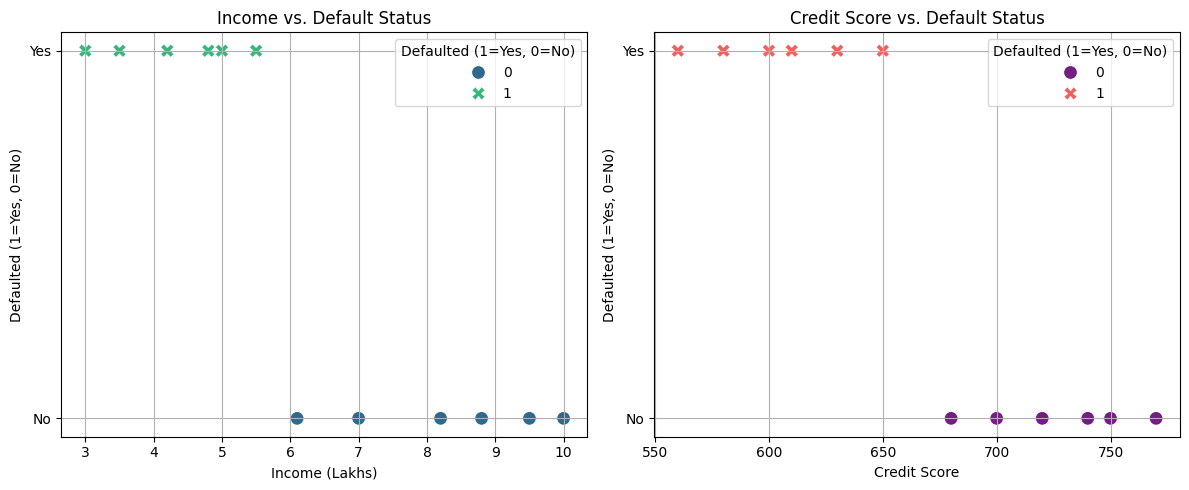


Training data points (LR): 9
Testing data points (LR): 3

Logistic Regression model trained successfully.

Coefficients (Income, Credit Score): [-0.95728616 -0.99809922]
Intercept: 0.33

Interpretation of Coefficients:
  - For Income: A coefficient of -0.96 suggests that as income increases, the log-odds of defaulting decrease significantly, holding credit score constant.
  - For Credit Score: A coefficient of -1.00 suggests that as credit score increases, the log-odds of defaulting decrease, holding income constant.
  - The Intercept (0.33) is the log-odds of default when all independent variables (Income and Credit Score) are zero (after scaling).

Predictions for test data (LR):


,Actual Default,Predicted Default,Probability of Default
8,1,1,0.668965
7,0,0,0.037342
9,0,0,0.021341



Confusion Matrix:


,Predicted No Default (0),Predicted Default (1)
Actual No Default (0),2,0
Actual Default (1),0,1



Model Evaluation Metrics (LR):
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1-Score: 1.00

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



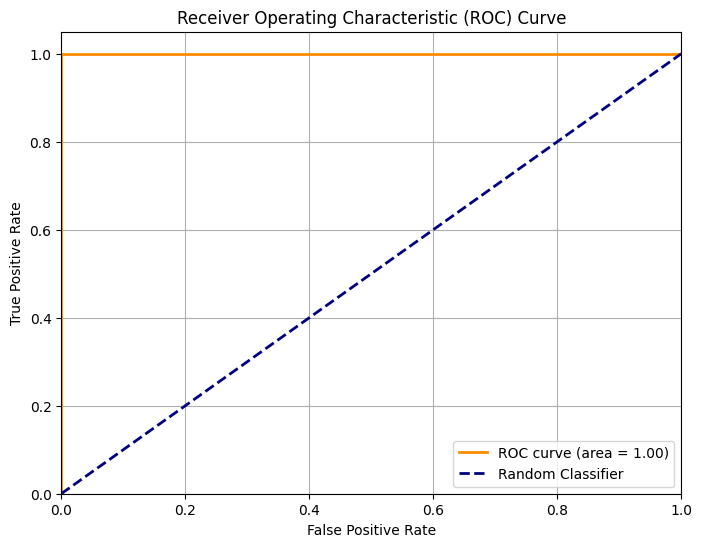

Area Under the Curve (AUC): 1.00

Predicted default status for a customer with Income 6.5 Lakhs and Credit Score 660: 0 (0=No, 1=Yes)
Probability of default: 0.43
This customer is predicted **not to default** on the loan.

--- Model Performance Explanation (Logistic Regression) ---
Accuracy: 1.00 - This is the proportion of total correct predictions (both defaults and non-defaults).
Precision: 1.00 - Of all customers predicted to default, 100% actually defaulted. This is important to minimize false positives (predicting default when there isn't one).
Recall: 1.00 - Of all actual defaulting customers, the model correctly identified 100%. This is important to minimize false negatives (failing to predict a default when there is one).
F1-Score: 1.00 - This is the harmonic mean of precision and recall, providing a balanced measure of the model's performance, especially useful when classes are imbalanced.
AUC Score: 1.00 - The Area Under the ROC Curve. An AUC of 1.00 indicates that the model

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

data_lr = {
    'Income (Lakhs)': [3.5, 4.2, 5.0, 6.1, 7.0, 8.2, 3.0, 9.5, 5.5, 10.0, 4.8, 8.8],
    'Credit Score': [580, 610, 650, 680, 700, 720, 560, 750, 630, 770, 600, 740],
    'Defaulted (1=Yes, 0=No)': [1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0]
}

df_lr = pd.DataFrame(data_lr)

print("Logistic Regression Dataset loaded successfully:")
display(df_lr.head())

print("\nBasic information about the dataset (LR):")
df_lr.info()

print("\nChecking for missing values (LR):")
display(df_lr.isnull().sum())

print("\nClass balance in 'Defaulted' column:")
display(df_lr['Defaulted (1=Yes, 0=No)'].value_counts())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x='Income (Lakhs)', y='Defaulted (1=Yes, 0=No)', hue='Defaulted (1=Yes, 0=No)', data=df_lr, palette='viridis', style='Defaulted (1=Yes, 0=No)', s=100)
plt.title('Income vs. Default Status')
plt.xlabel('Income (Lakhs)')
plt.ylabel('Defaulted (1=Yes, 0=No)')
plt.yticks([0, 1], ['No', 'Yes'])
plt.grid(True)

plt.subplot(1, 2, 2)
sns.scatterplot(x='Credit Score', y='Defaulted (1=Yes, 0=No)', hue='Defaulted (1=Yes, 0=No)', data=df_lr, palette='magma', style='Defaulted (1=Yes, 0=No)', s=100)
plt.title('Credit Score vs. Default Status')
plt.xlabel('Credit Score')
plt.ylabel('Defaulted (1=Yes, 0=No)')
plt.yticks([0, 1], ['No', 'Yes'])
plt.grid(True)

plt.tight_layout()
plt.show()

X_lr = df_lr[['Income (Lakhs)', 'Credit Score']]
y_lr = df_lr['Defaulted (1=Yes, 0=No)']

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y_lr, test_size=0.2, random_state=42, stratify=y_lr)

print(f"\nTraining data points (LR): {len(X_train_lr)}")
print(f"Testing data points (LR): {len(X_test_lr)}")

scaler = StandardScaler()
X_train_lr_scaled = scaler.fit_transform(X_train_lr)
X_test_lr_scaled = scaler.transform(X_test_lr)

log_reg_model = LogisticRegression(random_state=42)
log_reg_model.fit(X_train_lr_scaled, y_train_lr)

print("\nLogistic Regression model trained successfully.")

print(f"\nCoefficients (Income, Credit Score): {log_reg_model.coef_[0]}")
print(f"Intercept: {log_reg_model.intercept_[0]:.2f}")

print("\nInterpretation of Coefficients:")
print(f"  - For Income: A coefficient of {log_reg_model.coef_[0][0]:.2f} suggests that as income increases, the log-odds of defaulting decrease significantly, holding credit score constant.")
print(f"  - For Credit Score: A coefficient of {log_reg_model.coef_[0][1]:.2f} suggests that as credit score increases, the log-odds of defaulting decrease, holding income constant.")
print(f"  - The Intercept ({log_reg_model.intercept_[0]:.2f}) is the log-odds of default when all independent variables (Income and Credit Score) are zero (after scaling).")

y_pred_lr = log_reg_model.predict(X_test_lr_scaled)
y_proba_lr = log_reg_model.predict_proba(X_test_lr_scaled)[:, 1]

print("\nPredictions for test data (LR):")
predictions_df_lr = pd.DataFrame({'Actual Default': y_test_lr, 'Predicted Default': y_pred_lr, 'Probability of Default': y_proba_lr})
display(predictions_df_lr)

conf_matrix = confusion_matrix(y_test_lr, y_pred_lr)
print("\nConfusion Matrix:")
display(pd.DataFrame(conf_matrix, index=['Actual No Default (0)', 'Actual Default (1)'], columns=['Predicted No Default (0)', 'Predicted Default (1)']))

accuracy = accuracy_score(y_test_lr, y_pred_lr)
precision = precision_score(y_test_lr, y_pred_lr)
recall = recall_score(y_test_lr, y_pred_lr)
f1 = f1_score(y_test_lr, y_pred_lr)

print("\nModel Evaluation Metrics (LR):")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

print("\nClassification Report:")
print(classification_report(y_test_lr, y_pred_lr))

fpr, tpr, thresholds = roc_curve(y_test_lr, y_proba_lr)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"Area Under the Curve (AUC): {roc_auc:.2f}")

new_customer_features = pd.DataFrame({
    'Income (Lakhs)': [6.5],
    'Credit Score': [660]
})

new_customer_features_scaled = scaler.transform(new_customer_features)

predicted_default_new_customer = log_reg_model.predict(new_customer_features_scaled)[0]
predicted_proba_new_customer = log_reg_model.predict_proba(new_customer_features_scaled)[0][1]

print(f"\nPredicted default status for a customer with Income 6.5 Lakhs and Credit Score 660: {predicted_default_new_customer} (0=No, 1=Yes)")
print(f"Probability of default: {predicted_proba_new_customer:.2f}")

if predicted_default_new_customer == 1:
    print("This customer is predicted to **default** on the loan.")
else:
    print("This customer is predicted **not to default** on the loan.")

print("\n--- Model Performance Explanation (Logistic Regression) ---")

print(f"Accuracy: {accuracy:.2f} - This is the proportion of total correct predictions (both defaults and non-defaults).")
print(f"Precision: {precision:.2f} - Of all customers predicted to default, {precision*100:.0f}% actually defaulted. This is important to minimize false positives (predicting default when there isn't one).")
print(f"Recall: {recall:.2f} - Of all actual defaulting customers, the model correctly identified {recall*100:.0f}%. This is important to minimize false negatives (failing to predict a default when there is one).")
print(f"F1-Score: {f1:.2f} - This is the harmonic mean of precision and recall, providing a balanced measure of the model's performance, especially useful when classes are imbalanced.")
print(f"AUC Score: {roc_auc:.2f} - The Area Under the ROC Curve. An AUC of {roc_auc:.2f} indicates that the model has a high ability to distinguish between defaulting and non-defaulting customers. A score of 1.0 is perfect, and 0.5 is random guessing.")

if roc_auc > 0.85:
    performance_summary = "\nOverall, the Logistic Regression model performs very well in predicting loan default. The high AUC score, combined with good precision, recall, and F1-score (depending on the specific business need for balancing false positives and false negatives), suggests a robust model. The confusion matrix further breaks down correct and incorrect classifications."
elif roc_auc > 0.7:
    performance_summary = "\nOverall, the Logistic Regression model performs reasonably well. The AUC score suggests it's better than random guessing. Further tuning or more features might improve its performance, especially if there's a need to optimize specific metrics like precision or recall."
else:
    performance_summary = "\nOverall, the Logistic Regression model's performance is moderate or weak. The AUC score indicates limited discriminatory power. It might be necessary to reconsider features, use more advanced models, or collect more data to improve prediction accuracy."

print(performance_summary)
